In [4]:
import pandas as pd
import plotly.express as px

In [31]:
iteration_df = pd.read_csv('./results.csv')
holdout_df = pd.read_csv('./results-holdout.csv')
debug_holdout_df = pd.read_csv('./debug-holdout.csv')

In [32]:
iteration_df

,branch,datetime,overall_ratio,compressible_ratio,already_compressed_ratio,avg_compress_ms,avg_decompress_ms
0,stub,2026-05-21T01:06:17Z,1.000000,1.000000,1.000000,66.773,48.886
1,lzss-v1,2026-05-21T10:40:45Z,0.961035,0.945150,0.999425,355.136,42.409
2,lzss-v2,2026-05-21T10:56:59Z,0.948125,0.926935,0.999336,1036.773,61.591
3,lzss-v3,2026-05-21T20:37:08Z,0.873816,0.821981,0.999095,1208.409,179.136
4,lzss-v4,2026-05-22T04:48:56Z,0.773038,0.679660,0.998717,1816.818,215.159
5,lzss-v5,2026-05-24T10:12:24Z,0.742262,0.636150,0.998716,1937.409,219.295
6,lzss-v6,2026-05-25T01:40:36Z,0.727995,0.615980,0.998716,2107.045,235.182
7,lzss-v7,2026-05-26T03:20:15Z,0.712778,0.594468,0.998714,2460.227,241.000
8,lzss-v8,2026-05-26T04:40:19Z,0.711114,0.592141,0.998651,2844.000,238.636
9,lzss-v9,2026-05-27T02:40:13Z,0.703325,0.581131,0.998648,4800.705,233.659


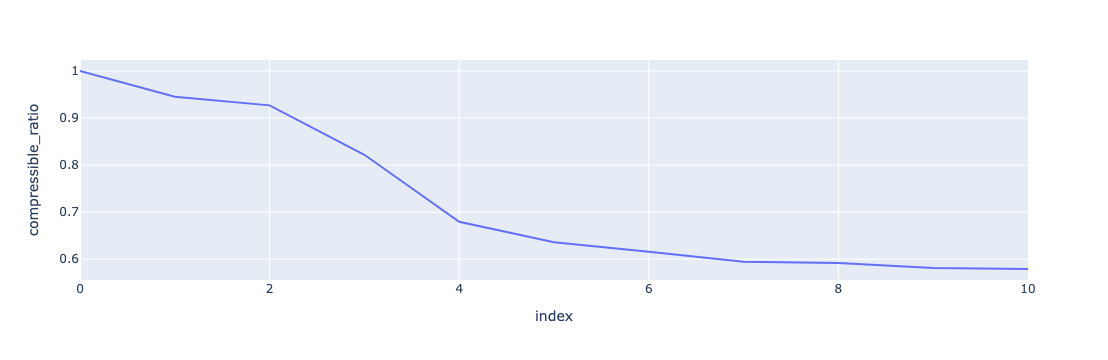

In [33]:
fig = px.line(iteration_df, x=iteration_df.index, y='compressible_ratio')
fig.show()

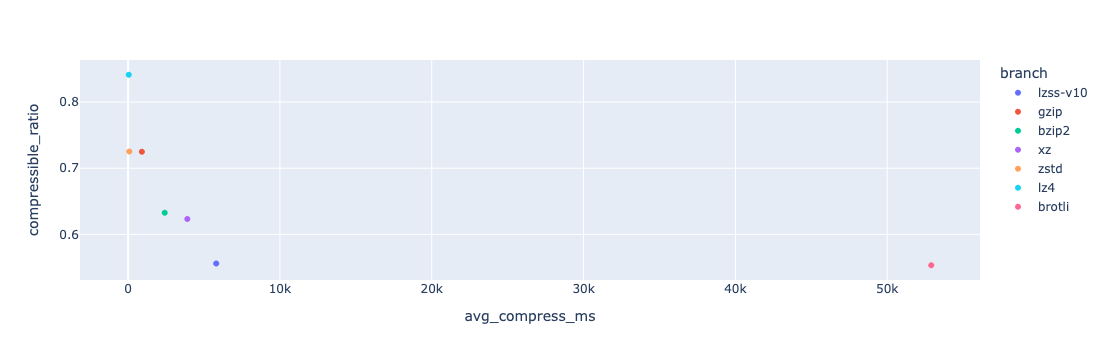

In [34]:
fig = px.scatter(holdout_df, x='avg_compress_ms', y='compressible_ratio', color='branch')
fig.show()

In [35]:
debug_holdout_df

,tool,filename,original_bytes,compressed_bytes,ratio,compress_ms,decompress_ms,type,compressible
0,lzss-v10,audio_beethoven_6_mov1.ogg,9651623,9518600,0.986218,766,73,audio,0
1,lzss-v10,audio_beethoven_6_mov1.wav,108582990,64820786,0.596970,22907,1026,audio,1
2,lzss-v10,audio_beethoven_6_mov4.ogg,3691158,3651846,0.989350,169,42,audio,0
3,lzss-v10,audio_beethoven_6_mov4.wav,42269262,25510525,0.603524,9085,411,audio,1
4,lzss-v10,audio_beethoven_8_mov4.ogg,9243270,9063515,0.980553,408,80,audio,0
...,...,...,...,...,...,...,...,...,...
296,brotli,text_sherlock_holmes.txt,607504,183982,0.302849,685,26,text,1
297,brotli,video_sintel_audio.wav,170508490,-1,-1.000000,-1,-1,video,1
298,brotli,video_sintel.mp4,77410288,76690993,0.990708,138582,398,video,0
299,brotli,video_tears_of_steel_audio.wav,129499342,-1,-1.000000,-1,-1,video,1


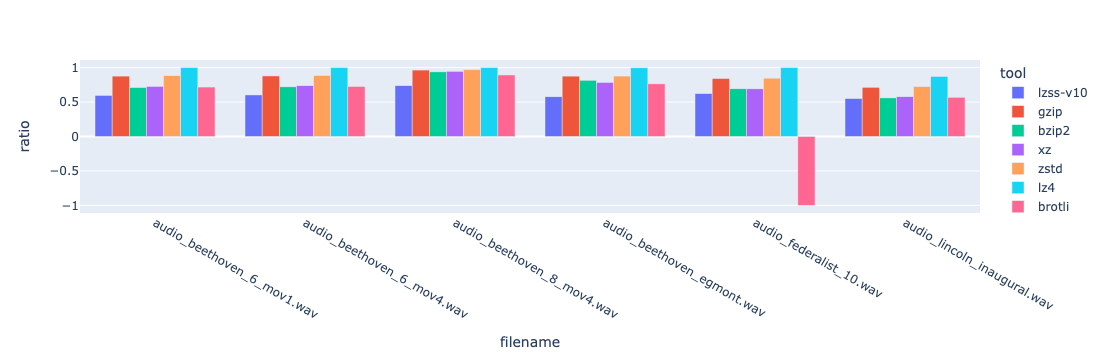

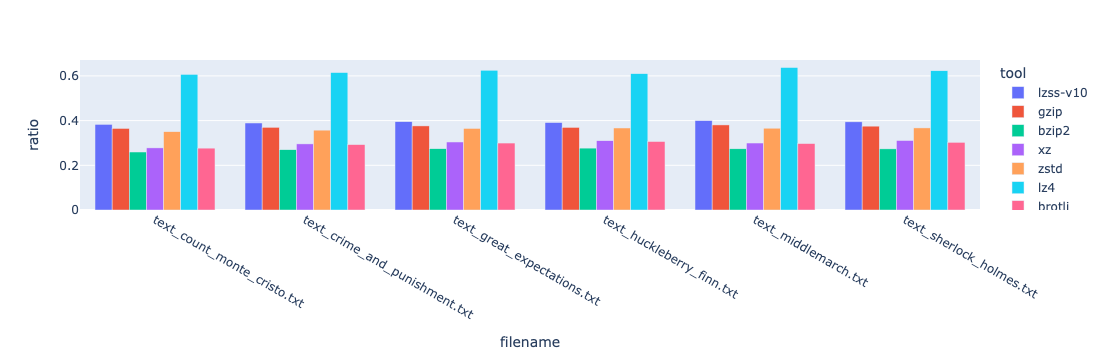

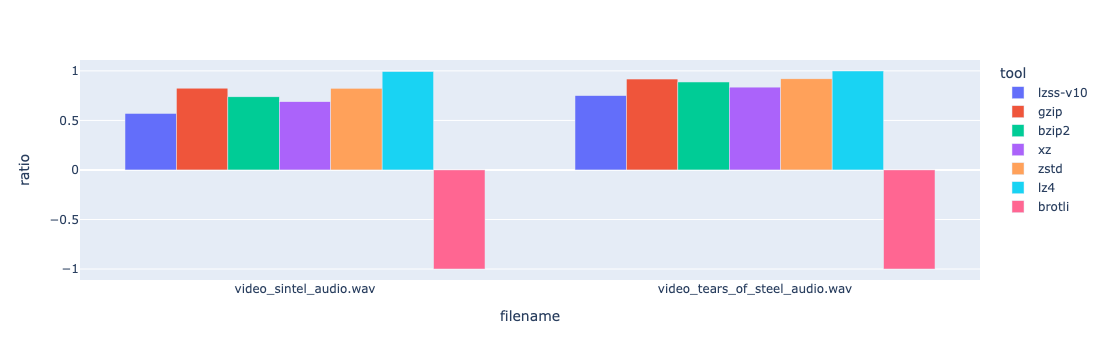

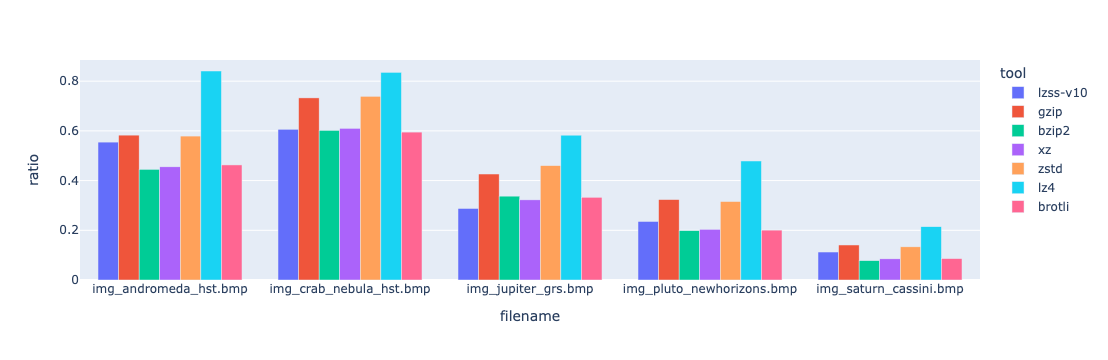

In [46]:
for t in ["audio", "text", "video", "image"]:
    fig = px.bar(debug_holdout_df[(debug_holdout_df["compressible"] == 1) & (debug_holdout_df["type"] == t)], x='filename', y='ratio', color='tool', barmode='group')
    fig.show()